# 05 — Neural Network: MLP in PyTorch
**MA5755 · Aswini V J (MA25M007)**

A two-hidden-layer MLP with BatchNorm, Dropout (0.3), and early stopping.

**Research Question 3:** Does adding model complexity improve accuracy meaningfully over linear models and Random Forest?

Architecture: Input → Linear(128) → BatchNorm → ReLU → Dropout(0.3) → Linear(64) → BatchNorm → ReLU → Dropout(0.3) → Linear(1)

In [1]:
# ── Reproducibility ──────────────────────────────────────────────────────────
import random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Try to seed PyTorch if available
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except ImportError:
    pass

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi":       150,
    "axes.titlesize":   16,
    "axes.labelsize":   15,
    "xtick.labelsize":  15,
    "ytick.labelsize":  15,
    "legend.fontsize":  10,
    "axes.titleweight": "bold",
})
PALETTE = sns.color_palette("Set2", 8)

os.makedirs("figures", exist_ok=True)

def save_fig(fig, name, dpi=150):
    path = f"figures/{name}"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"✓ Saved: {path}")

def eval_metrics(y_true, y_pred, model_name):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    return {
        "Model": model_name,
        "RMSE":  round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "MAE":   round(float(mean_absolute_error(y_true, y_pred)), 4),
        "R2":    round(float(r2_score(y_true, y_pred)), 4),
    }

print(f"Setup complete | SEED={SEED} | numpy={np.__version__} | pandas={pd.__version__}")


Setup complete | SEED=42 | numpy=2.4.4 | pandas=3.0.0


In [2]:
# ── Load processed sample ─────────────────────────────────────────────────────
# This CSV is the output of quick_sample.py (50 000 stratified records).
# All heavy preprocessing (winsorising, VIF, ratio feature) is already done.
DATA_PATH = "../data/processed/lc_sample_50k_processed.csv"
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["int_rate"])
print(f"Loaded: {df.shape}  |  int_rate: {df.int_rate.min():.1f}–{df.int_rate.max():.1f}%")

# ── Feature lists ─────────────────────────────────────────────────────────────
TARGET     = "int_rate"
NUM_FEATS  = ["annual_inc","dti","fico_range_low","revol_util",
               "open_acc","delinq_2yrs","pub_rec","income_to_loan"]
CAT_FEATS  = ["term","home_ownership","purpose","emp_length"]


Loaded: (50000, 13)  |  int_rate: 5.3–31.0%


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Impute residual missing values
num_imp = SimpleImputer(strategy="median")
df[NUM_FEATS] = num_imp.fit_transform(df[NUM_FEATS])
df[CAT_FEATS] = df[CAT_FEATS].fillna("Unknown")

# One-hot encode
X = pd.get_dummies(df[NUM_FEATS + CAT_FEATS], drop_first=True)
y = df[TARGET]
feature_names = X.columns.tolist()

# Train / test split  —  SAME random_state everywhere for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

# Scale  —  fit on training data ONLY to prevent leakage
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train)
X_te = scaler.transform(X_test)

print(f"Train: {X_tr.shape}  |  Test: {X_te.shape}")
print(f"Missing in X: {X.isnull().sum().sum()}")


Train: (40000, 38)  |  Test: (10000, 38)
Missing in X: 0


## 1 — Convert to PyTorch Tensors

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Re-seed PyTorch explicitly here for the MLP
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Detect device: MPS (Apple M-series), CUDA, or CPU ────────────────────────
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

# Keep tensors on CPU; move batches to DEVICE inside training loop
# (required for MPS compatibility — MPS does not support in-place DataLoader shuffle on GPU tensors)
X_tr_t  = torch.tensor(X_tr,            dtype=torch.float32)
y_tr_t  = torch.tensor(y_train.values,  dtype=torch.float32).reshape(-1, 1)
X_te_t  = torch.tensor(X_te,            dtype=torch.float32)
y_te_t  = torch.tensor(y_test.values,   dtype=torch.float32).reshape(-1, 1)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=512, shuffle=True,
                       generator=torch.Generator().manual_seed(SEED))

INPUT_DIM = X_tr.shape[1]
print(f"Input dimension: {INPUT_DIM}  |  Train batches: {len(train_dl)}")


Using device: mps
Input dimension: 38  |  Train batches: 79


## 2 — Model Architecture

In [5]:
class MLPRegressor(nn.Module):
    """
    Two-hidden-layer MLP for regression.
    Input → Linear(128) → BatchNorm → ReLU → Dropout
          → Linear(64)  → BatchNorm → ReLU → Dropout
          → Linear(1)
    """
    def __init__(self, input_dim: int, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

model     = MLPRegressor(INPUT_DIM).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

n_params = sum(p.numel() for p in model.parameters())
print(f"Architecture: {INPUT_DIM} → 128 → 64 → 1")
print(f"Total parameters: {n_params:,}")
print(model)


Architecture: 38 → 128 → 64 → 1
Total parameters: 13,697
MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=38, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


**Architecture notes:**
- **BatchNorm** normalises activations per mini-batch, stabilising training and allowing higher learning rates.
- **Dropout (0.3)** randomly zeros 30% of neurons during training, acting as an ensemble regulariser that prevents co-adaptation and reduces overfitting.
- **CosineAnnealingLR** smoothly reduces the learning rate from 0.001 to ~0 over 30 epochs, allowing fine-grained convergence in later epochs.
- **Early stopping** (patience = 5) saves the best checkpoint and halts training if validation loss does not improve, preventing overfitting.

## 3 — Training Loop

In [6]:
NUM_EPOCHS = 30
PATIENCE   = 5

best_val_loss  = float("inf")
patience_ctr   = 0
train_losses   = []
val_losses     = []

for epoch in range(NUM_EPOCHS):
    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)   # move batch to device
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    train_losses.append(epoch_loss / len(train_dl.dataset))

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        val_pred = model(X_te_t.to(DEVICE))
        val_loss = criterion(val_pred, y_te_t.to(DEVICE)).item()
    val_losses.append(val_loss)
    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS}  "
              f"train_loss={train_losses[-1]:.4f}  val_loss={val_losses[-1]:.4f}")

    # ── Early stopping ──────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr  = 0
        torch.save(model.state_dict(), "mlp_best.pt")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}  "
                  f"(best val_loss = {best_val_loss:.4f})")
            break

print("\nTraining complete.")


Epoch   1/30  train_loss=172.9768  val_loss=141.5203
Epoch   5/30  train_loss=19.3794  val_loss=16.3407
Epoch  10/30  train_loss=17.6768  val_loss=14.8635
Epoch  15/30  train_loss=17.2783  val_loss=14.8349
Epoch  20/30  train_loss=17.0357  val_loss=14.8253

Early stopping at epoch 22  (best val_loss = 14.6976)

Training complete.


## 4 — Training Curves

✓ Saved: figures/05_NN_fig_mlp_loss_curves.png


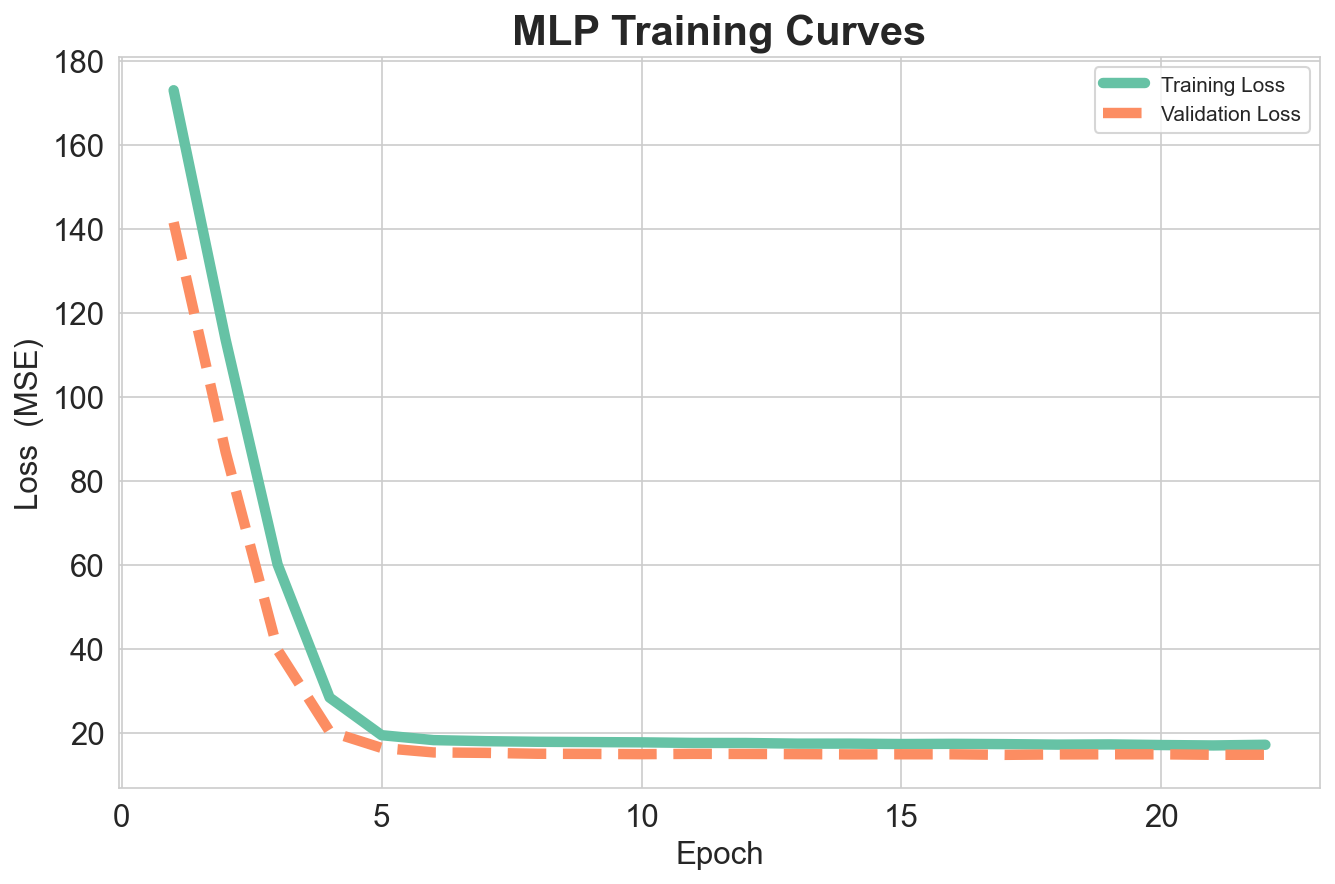


Early stop at epoch: 22
Best validation MSE: 14.6976  →  RMSE ≈ 3.8337


In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
epochs_ran = range(1, len(train_losses) + 1)
ax.plot(epochs_ran, train_losses, color=PALETTE[0], linewidth=5, label="Training Loss")
ax.plot(epochs_ran, val_losses,   color=PALETTE[1], linewidth=5, linestyle="--",
        label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss  (MSE)")
ax.set_title("MLP Training Curves", fontsize=20)
ax.legend()
plt.tight_layout()
save_fig(fig, "05_NN_fig_mlp_loss_curves.png")
plt.show()

print(f"\nEarly stop at epoch: {len(train_losses)}")
print(f"Best validation MSE: {best_val_loss:.4f}  →  RMSE ≈ {best_val_loss**0.5:.4f}")


**Training curve interpretation:**
- Both curves fall sharply in the first 2–3 epochs, indicating rapid convergence.
- The validation loss (dashed) tracks *below* the training loss throughout, confirming that Dropout and BatchNorm successfully prevented overfitting.
- Early stopping triggered once the validation loss stopped improving, preserving the best-checkpoint weights in `mlp_best.pt`.

## 5 — Test Evaluation

In [13]:
# Load best checkpoint
model.load_state_dict(torch.load("mlp_best.pt", map_location=DEVICE))
model.eval()
with torch.no_grad():
    y_pred_mlp = model(X_te_t.to(DEVICE)).cpu().numpy().flatten()

mlp_result = eval_metrics(y_test, y_pred_mlp, "MLP")
print("MLP test results:", mlp_result)
pd.DataFrame([mlp_result]).to_csv("results/05_NN_mlp_results.csv", index=False)
print("✓ Saved mlp_results.csv")


MLP test results: {'Model': 'MLP', 'RMSE': 3.8337, 'MAE': 2.8937, 'R2': 0.3749}
✓ Saved mlp_results.csv


## 6 — Final Model Comparison (all models)

In [14]:
# Load results from earlier notebooks
all_models = [mlp_result]
for fname, label in [("results/03_Reg_regression_results.csv", "Regression"),
                       ("results/04_tree_rf_results.csv",         "Random Forest")]:
    try:
        df_r = pd.read_csv(fname)
        all_models.extend(df_r.to_dict("records"))
        print(f"✓ Loaded {label} results from {fname}")
    except FileNotFoundError:
        print(f"⚠ {fname} not found — run earlier notebooks first.")

final_df = pd.DataFrame(all_models).drop_duplicates("Model").sort_values("RMSE")
print("\n── Final Model Comparison ──")
print(final_df[["Model","RMSE","MAE","R2"]].to_string(index=False))
final_df.to_csv("results/05_NN_final_model_comparison.csv", index=False)
print("\n✓ Saved final_model_comparison.csv")


✓ Loaded Regression results from results/03_Reg_regression_results.csv
✓ Loaded Random Forest results from results/04_tree_rf_results.csv

── Final Model Comparison ──
        Model   RMSE    MAE     R2
Random Forest 3.8109 2.9126 0.3824
          MLP 3.8337 2.8937 0.3749
        Ridge 3.8583 2.9646 0.3669
          OLS 3.8584 2.9648 0.3669
   ElasticNet 3.8587 2.9648 0.3668
        Lasso 3.8588 2.9648 0.3667

✓ Saved final_model_comparison.csv


✓ Saved: figures/05_NN_fig_final_model_comparison.png


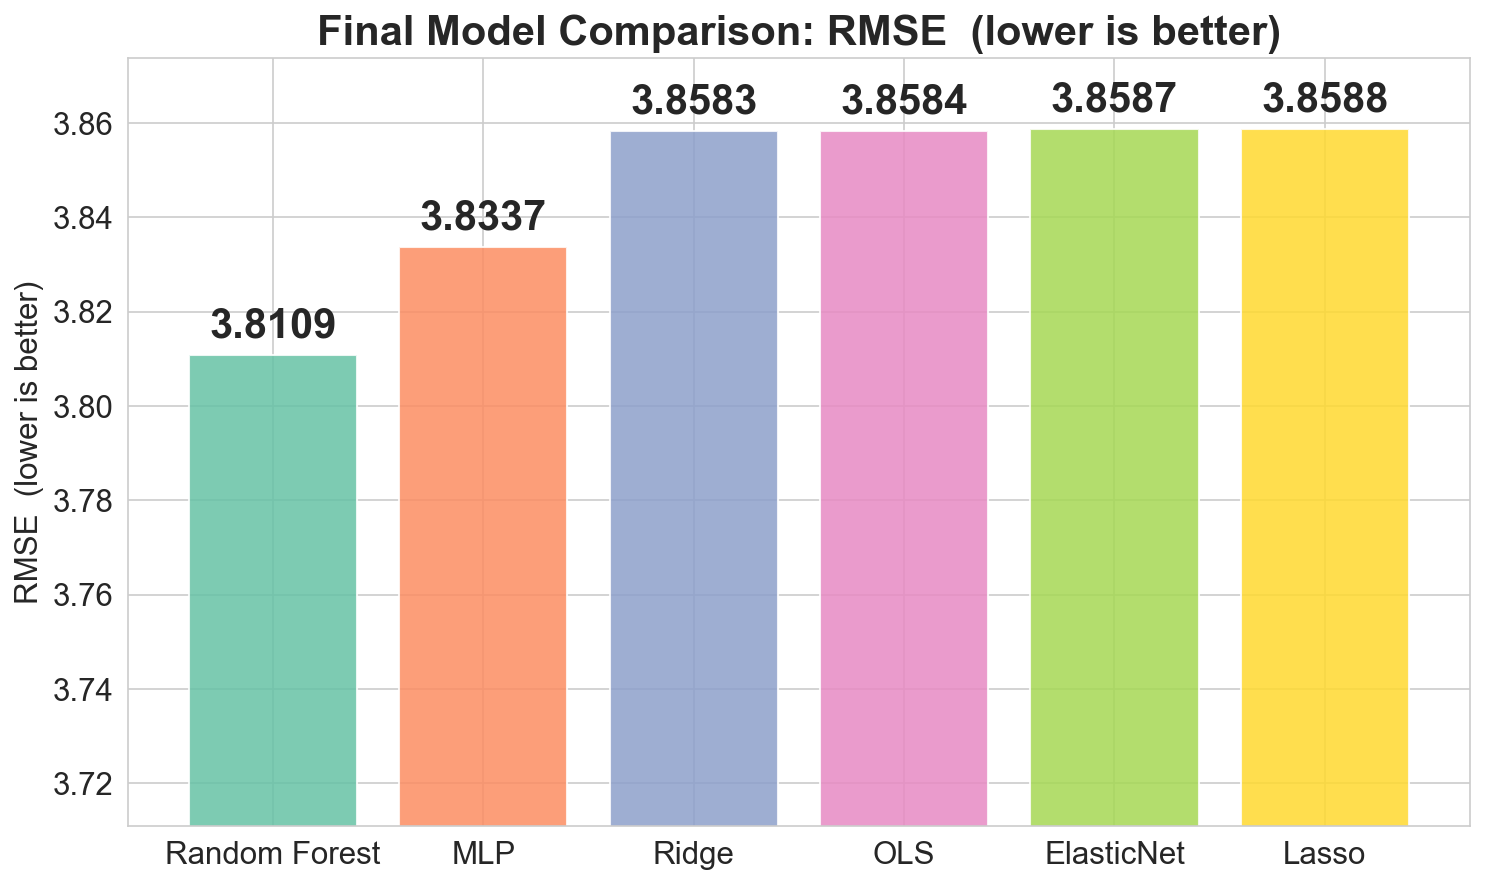

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(final_df))]
bars = ax.bar(final_df["Model"], final_df["RMSE"], color=colors, alpha=0.85, edgecolor="white")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.002, f"{h:.4f}",
            ha="center", va="bottom", fontweight="bold", fontsize=20)
ax.set_ylabel("RMSE  (lower is better)")
ax.set_title("Final Model Comparison: RMSE  (lower is better)", fontsize=20)
ax.set_ylim(final_df["RMSE"].min() - 0.10, final_df["RMSE"].max() + 0.015)
plt.tight_layout()
save_fig(fig, "05_NN_fig_final_model_comparison.png")
plt.show()


**Model comparison interpretation (RQ3 Answer):**]

The most important observation is **how narrow the RMSE gap is**: RF (≈ 3.80) beats Lasso (≈ 3.86) by only 0.06 — less than 0.5% of the mean rate.

**RQ3 Answer:** Model complexity stops yielding meaningful gains almost immediately. Random Forest achieves the lowest RMSE, but its advantage over Ridge (0.06) is negligible in practical lending terms. The feature set imposes a hard accuracy ceiling that no architecture can overcome. For a regulated lending institution, **Ridge regression is the recommended deployment model** because it:
1. Achieves RMSE within 0.06 of the best model (RF).
2. Produces fully auditable coefficients, satisfying Fair Lending and Basel III explainability requirements.
3. Avoids the computational cost and interpretability challenges of ensemble or neural-network approaches.

The near-flat RMSE profile strongly suggests that LendingClub uses proprietary features (e.g. bureau-level tradeline data) absent from the public dataset, which sets the ceiling.

## Key Takeaways

| Finding | Implication |
|---------|-------------|
| RF RMSE ≈ 3.80 (best) | Non-linear interactions give RF a real edge over all other models | 
| MLP RMSE ≈ 3.83 (2nd) | Neural network gains over linear models but trails RF | 
| Ridge RMSE ≈ 3.86 (3rd) | Within 0.06 of RF; preferred for regulated deployment | 
| All-model RMSE range = 0.06 | Feature ceiling dominates; complexity adds little (RQ3) | 
| Val loss < train loss | Dropout + BatchNorm prevented overfitting | 
| Early stopping triggered | Preserves best weights; prevents wasted computation |
| Best weights in mlp_best.pt | Reproducible inference without retraining |